# Assignment 2: Exploratory Data Analysis (EDA)
### Fashion Intelligence System, COSC2753 Machine Learning

This notebook explores `styles_train.csv` to understand the data before any preprocessing or modelling. There are four prediction targets:

| Task | Target label |
|------|--------------|
| Task 1 | `articleType` (product type) |
| Task 2 | `season` |
| Task 3 | `gender` and `usage` (gender and occasion) |
| Task 4 | Visual Search (image similarity, uses images rather than labels) |

The goal here is only to describe what the data looks like and where the problems are. Preprocessing choices and modelling decisions come later, once the whole group has agreed on how to handle each issue.


## 0. Setup: paths and libraries

Paths are kept in one place so we can switch between local and Kaggle or Colab later. (Java/C++ analogy: this block is like declaring the `static final` path constants at the top of a program.)


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110

# Paths (change this one place when running on Kaggle or Colab).
# The notebook lives in notebooks/, so data sits at ../data/
DATA_DIR   = os.path.join('..', 'data')
TRAIN_CSV  = os.path.join(DATA_DIR, 'train', 'styles_train.csv')
TRAIN_IMG  = os.path.join(DATA_DIR, 'train', 'images_train')
TEST_CSV   = os.path.join(DATA_DIR, 'test',  'styles_prediction.csv')
TEST_IMG   = os.path.join(DATA_DIR, 'test',  'images_test')

print('Train CSV exists:', os.path.exists(TRAIN_CSV))
print('Train image folder exists:', os.path.exists(TRAIN_IMG))
print('Test CSV exists:', os.path.exists(TEST_CSV))
print('Test image folder exists:', os.path.exists(TEST_IMG))

Train CSV exists: True
Train image folder exists: True
Test CSV exists: True
Test image folder exists: True


## 1. Data loading and integrity checks

We check the structure of the file, missing values, duplicates, and anomalous values before looking at anything else.


In [2]:
df_raw = pd.read_csv(TRAIN_CSV, on_bad_lines='skip')
print('Raw shape:', df_raw.shape)
print('Columns:', list(df_raw.columns))
df_raw.head()

Raw shape: (38617, 12)
Columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'Unnamed: 10', 'Unnamed: 11']


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,Unnamed: 10,Unnamed: 11
0,1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,NaN,NaN
1,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,NaN,NaN
2,1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013,Sports,Nike Mean Team India Cricket Jersey,NaN,NaN
3,1525,Unisex,Accessories,Bags,Backpacks,Navy Blue,Fall,2010,Casual,Puma Deck Navy Blue Backpack,NaN,NaN
4,1526,Unisex,Accessories,Bags,Backpacks,Black,Fall,2010,Sports,Puma Big Cat Backpack Black,NaN,NaN


### 1.1. Two unexpected columns: `Unnamed: 10` and `Unnamed: 11`

The file loads with 12 columns, but the specification only defines 10 fields. We look at what is in the two extra columns before deciding anything.


In [3]:
extra_cols = [c for c in df_raw.columns if c.startswith('Unnamed')]
print('Extra columns:', extra_cols)
for c in extra_cols:
    print(f'  {c}: {df_raw[c].notna().sum()} non-null rows')

mask_extra = df_raw[extra_cols].notna().any(axis=1)
print(f'\nTotal rows affected: {mask_extra.sum()}')
df_raw.loc[mask_extra, ['id', 'productDisplayName'] + extra_cols].head(10)

Extra columns: ['Unnamed: 10', 'Unnamed: 11']
  Unnamed: 10: 21 non-null rows
  Unnamed: 11: 2 non-null rows

Total rows affected: 21


,id,productDisplayName,Unnamed: 10,Unnamed: 11
1320,3413,Myntra Men's Yes,its all about me White T-shirt,NaN
1325,3418,Myntra Men's Take my advice,I don't use it anyway Black T-shirt,NaN
1335,3428,Myntra Mens Be Reasonable,Do It My Way T-shirt,NaN
2689,4854,Newfeel Unisex White,Blue and Orange Casual Shoes,NaN
17899,23100,Turtle Men Formal Navy Blue Tie,Cufflink and Pocket Square Combo Set,NaN
17900,23101,Turtle Men Formal Pink Tie,Cufflink and Pocket Square Combo Set,NaN
17902,23103,Turtle Men Formal Black Tie,Cufflink and Pocket Square Combo Set,NaN
17906,23107,Turtle Men Formal Purple Tie,Cufflink and Pocket Square Combo Set,NaN
17907,23108,Turtle Men Formal Purple Tie,Cufflink and Pocket Square Combo Set,NaN
17908,23109,Turtle Men Formal Purple Tie,Cufflink and Pocket Square Combo Set,NaN


Only 21 rows have any value in these columns. Looking at those rows, the cause is clear: some `productDisplayName` values contain a comma (for example `"Myntra Men's Yes, its all about me White T-shirt"`). Because the file is comma-separated and those names are not wrapped in quotes, the parser splits the text after the comma into new columns.

So this is a parsing artefact in the `productDisplayName` text, not corrupted data. `productDisplayName` is a description field and is not one of the four prediction targets, so the four labels themselves are unaffected. For the analysis below we work on a copy with the fragments rejoined and the extra columns removed, so the column count is correct.


In [4]:
df = df_raw.copy()

def merge_name(row):
    parts = [row['productDisplayName']]
    for c in extra_cols:
        if pd.notna(row[c]):
            parts.append(str(row[c]))
    return ','.join([str(p) for p in parts if pd.notna(p)])

df['productDisplayName'] = df.apply(merge_name, axis=1)
df = df.drop(columns=extra_cols)

print('Shape after rejoining names and dropping extra columns:', df.shape)
print('Remaining columns:', list(df.columns))

Shape after rejoining names and dropping extra columns: (38617, 10)
Remaining columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']


### 1.2. Missing values

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(3)
missing_tbl = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
print(missing_tbl)
print(f'\nTotal rows: {len(df)}')

                    missing_count  missing_%
id                              0      0.000
gender                          0      0.000
masterCategory                  0      0.000
subCategory                     0      0.000
articleType                     0      0.000
baseColour                     14      0.036
season                         20      0.052
year                            0      0.000
usage                          72      0.186
productDisplayName              0      0.000

Total rows: 38617


In [6]:
# Do the rows missing season and the rows missing usage overlap?
n_both = (df['season'].isna() & df['usage'].isna()).sum()
print(f'Rows missing both season and usage: {n_both}')

Rows missing both season and usage: 0


Missing values are very small in every column. Among the prediction targets, `season` is missing in 20 rows (about 0.05%) and `usage` in 72 rows (about 0.19%); `gender` and `articleType` have none. Outside the targets, `baseColour` is missing in 14 rows and `productDisplayName` in 7. The rows missing `season` and the rows missing `usage` do not overlap, so the gaps sit in different records rather than a few broken rows.


### 1.3. Duplicates

In [7]:
print('Duplicate ids:', df['id'].duplicated().sum())
print('Fully duplicate rows (every column identical):', df.duplicated().sum())

Duplicate ids: 0
Fully duplicate rows (every column identical): 0


There are no duplicate `id` values and no fully duplicated rows. The `id` column behaves like a unique key, so there is nothing to deduplicate.


### 1.4. Label formatting consistency

In [8]:
for col in ['gender', 'season', 'usage', 'articleType']:
    vals = df[col].dropna().unique()
    stripped = {v.strip() for v in vals}
    lowered = {v.lower().strip() for v in vals}
    print(f'{col:12s}: {len(vals):3d} raw | {len(stripped):3d} after strip | {len(lowered):3d} after lower+strip')

gender      :   5 raw |   5 after strip |   5 after lower+strip
season      :   4 raw |   4 after strip |   4 after lower+strip
usage       :   8 raw |   8 after strip |   8 after lower+strip
articleType : 125 raw | 125 after strip | 125 after lower+strip


All four label columns are clean in formatting. The raw, stripped, and lower-cased unique counts match for every column, so there are no stray spaces or inconsistent capitalisation splitting one real class into two (for example `"Casual"` and `"casual "`). The class counts reported below are therefore the true class counts.


### 1.5. Overall

The data is structurally clean: `id` is unique, there are no duplicate rows, missing values are negligible, and the labels are consistently formatted. The one structural issue found (the two extra columns) affects only the description text, not the targets. The substantive difficulty in this dataset is not data quality but the distribution of the labels, which the next section examines.


## 2. Distribution of the four prediction targets

This is the main part of the EDA. Each of the four targets has a very different shape, which is what makes the four tasks hard in different ways. This section only describes the distributions and points out the problems in each one. How to handle them is left for the group to decide.


In [22]:
labels = ['gender', 'articleType', 'season', 'usage']

summary = []
for col in labels:
    vc = df[col].value_counts(dropna=True)
    summary.append({
        'label': col,
        'n_classes': len(vc),
        'largest_class': vc.index[0],
        'largest_count': int(vc.iloc[0]),
        'largest_%': round(vc.iloc[0] / vc.sum() * 100, 1),
        'smallest_count': int(vc.iloc[-1]),
        'imbalance_ratio': round(vc.iloc[0] / vc.iloc[-1], 1),
    })
summary_df = pd.DataFrame(summary)
summary_df

,label,n_classes,largest_class,largest_count,largest_%,smallest_count,imbalance_ratio
0,gender,5,Men,20918,54.2,645,32.4
1,articleType,125,Tshirts,6781,17.6,1,6781.0
2,season,4,Summer,19137,49.6,1567,12.2
3,usage,8,Casual,29641,76.9,1,29641.0


The summary table shows how differently the four targets are distributed. `season` is the most even (4 classes, largest about 50%). `gender` has 5 classes and is moderately skewed. `articleType` spreads across 125 classes with a very long tail. `usage` is dominated by a single class. The imbalance ratio (largest class divided by smallest) makes the gap concrete: it is about 12 for `season`, but reaches into the thousands for `articleType` and `usage`. Each target is plotted below.


### 2.1. `gender` (Task 3)

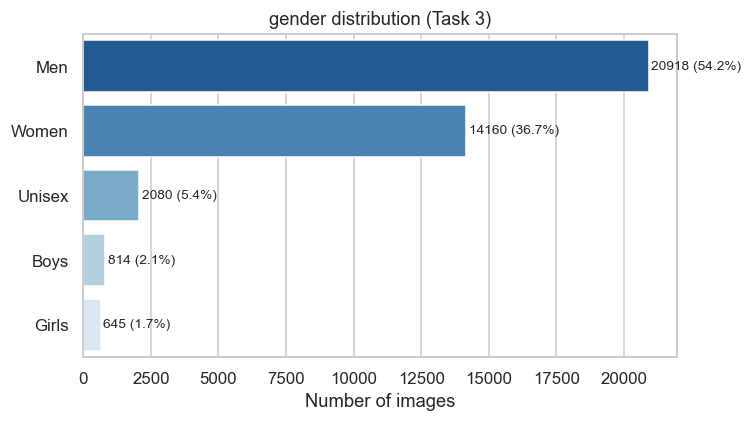

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
vc = df['gender'].value_counts()
sns.barplot(x=vc.values, y=vc.index, ax=ax, palette='Blues_r', hue=vc.index, legend=False)
ax.set_title('gender distribution (Task 3)')
ax.set_xlabel('Number of images'); ax.set_ylabel('')
for i, v in enumerate(vc.values):
    ax.text(v + 100, i, f'{v} ({v/vc.sum()*100:.1f}%)', va='center', fontsize=9)
plt.tight_layout(); plt.show()

Men and Women together account for roughly 91% of the data. Boys and Girls combined are only about 3.8%. There is also a `Unisex` class, which is a valid label rather than an error. The distribution is skewed but the smallest classes still have several hundred images each.


### 2.2. `season` (Task 2)

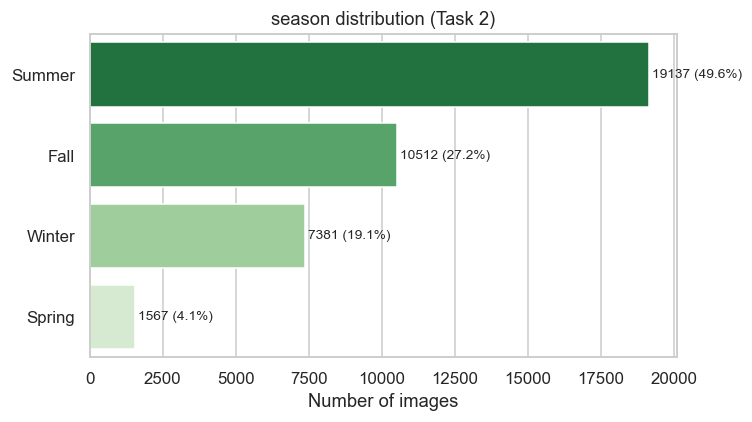

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
vc = df['season'].value_counts()
sns.barplot(x=vc.values, y=vc.index, ax=ax, palette='Greens_r', hue=vc.index, legend=False)
ax.set_title('season distribution (Task 2)')
ax.set_xlabel('Number of images'); ax.set_ylabel('')
for i, v in enumerate(vc.values):
    ax.text(v + 100, i, f'{v} ({v/vc.sum()*100:.1f}%)', va='center', fontsize=9)
plt.tight_layout(); plt.show()

This is the most balanced of the four targets, running from Summer at about 50% down to Spring at about 4%. One thing to keep in mind, and to check at the modelling stage rather than now, is that the season of a product may not be strongly visible in its image: a plain white t-shirt could be tagged Summer or Winter with little in the picture to tell them apart. Whether the visual signal is strong enough to predict season is an open question at this point.


### 2.3. `articleType` (Task 1)

In [12]:
vc = df['articleType'].value_counts()
print(f'Total classes: {len(vc)}')
print(f'Classes with only 1 image: {(vc == 1).sum()}')
print(f'Classes with <= 5 images:  {(vc <= 5).sum()}')
print(f'Classes with <= 10 images: {(vc <= 10).sum()}')

cum = vc.cumsum() / vc.sum()
n80 = int((cum <= 0.80).sum()) + 1
print(f'\nThe top {n80} of {len(vc)} classes account for 80% of the data.')

Total classes: 125
Classes with only 1 image: 7
Classes with <= 5 images:  24
Classes with <= 10 images: 33

The top 21 of 125 classes account for 80% of the data.


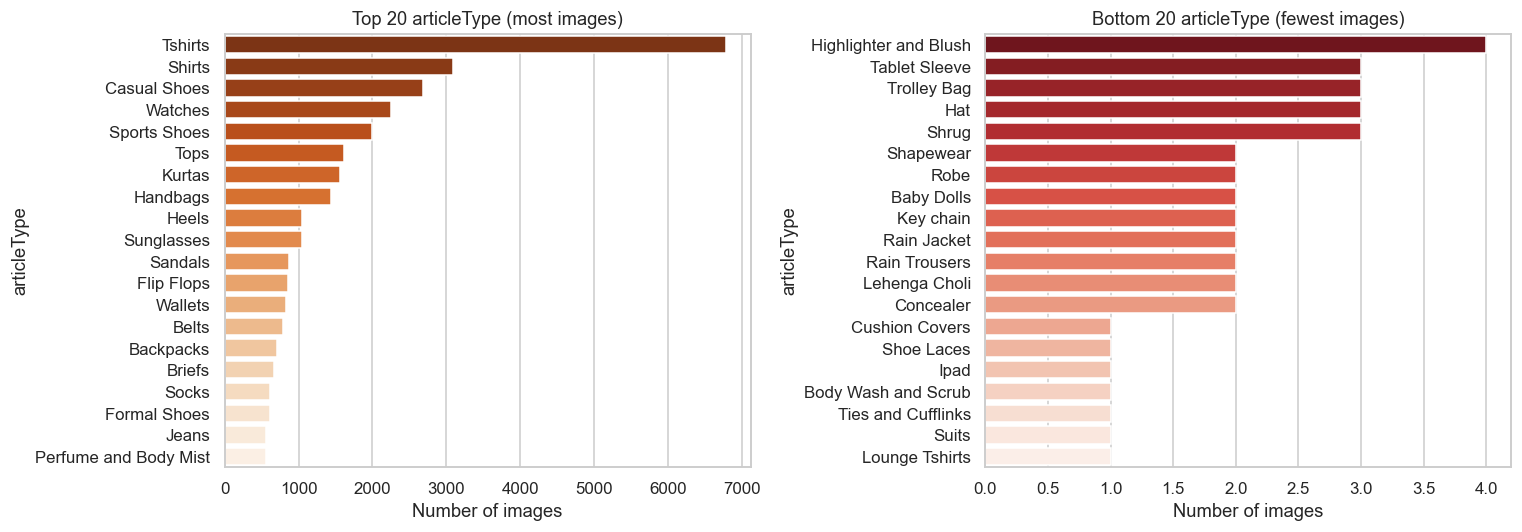

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top20 = vc.head(20)
sns.barplot(x=top20.values, y=top20.index, ax=axes[0], palette='Oranges_r', hue=top20.index, legend=False)
axes[0].set_title('Top 20 articleType (most images)')
axes[0].set_xlabel('Number of images')

bot20 = vc.tail(20)
sns.barplot(x=bot20.values, y=bot20.index, ax=axes[1], palette='Reds_r', hue=bot20.index, legend=False)
axes[1].set_title('Bottom 20 articleType (fewest images)')
axes[1].set_xlabel('Number of images')

plt.tight_layout(); plt.show()

This is the hardest target in terms of distribution. There are 125 classes, but only about 21 of them make up 80% of the data, so the rest form a long tail. At the very end of that tail, 7 classes have exactly 1 image and 24 have 5 or fewer. Classes with a single image cannot be placed in both a training and a validation split, and classes with only a handful of images give a model almost nothing to learn from. The gap between the largest class (Tshirts) and the smallest is several thousand-fold.


### 2.4. `usage` (Task 3)

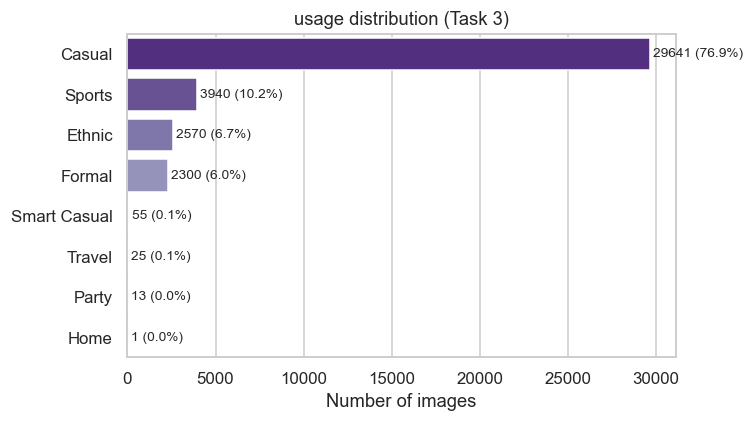

Breakdown:
usage
Casual          29641
Sports           3940
Ethnic           2570
Formal           2300
Smart Casual       55
Travel             25
Party              13
Home                1
Name: count, dtype: int64


In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
vc = df['usage'].value_counts()
sns.barplot(x=vc.values, y=vc.index, ax=ax, palette='Purples_r', hue=vc.index, legend=False)
ax.set_title('usage distribution (Task 3)')
ax.set_xlabel('Number of images'); ax.set_ylabel('')
for i, v in enumerate(vc.values):
    ax.text(v + 200, i, f'{v} ({v/vc.sum()*100:.1f}%)', va='center', fontsize=9)
plt.tight_layout(); plt.show()

print('Breakdown:')
print(vc)

This is the most heavily skewed target. Casual alone makes up about 77% of all rows. The practical consequence is that plain accuracy is a weak measure here: a model that predicts Casual for every image would already score around 77% without learning anything. At the other end, several classes are extremely rare, including Home with 1 image, Party with 13, Travel with 25, and Smart Casual with 55.


## 3. Relationships between labels and supporting columns

`masterCategory`, `subCategory`, `baseColour`, and `year` are not prediction targets, but they give useful context about the data.


### 3.1. How the labels relate to each other

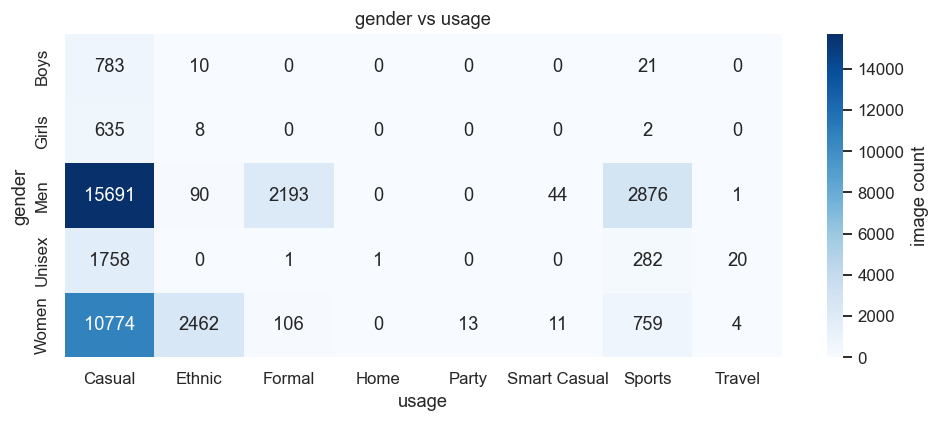

In [15]:
# Each image carries all four labels at once, so the labels are not independent.
ct = pd.crosstab(df['gender'], df['usage'])
plt.figure(figsize=(9, 4))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'image count'})
plt.title('gender vs usage')
plt.tight_layout(); plt.show()

Because every image has all four labels at once, the labels are related rather than independent. For example, Formal usage appears mostly with Men and Women and almost never with Boys or Girls, and Ethnic usage sits overwhelmingly with Women. These relationships are worth noting because they mean the four tasks are not really separate problems on the same images; the label combinations are uneven, and some combinations barely occur.


### 3.2. `usage` across product categories

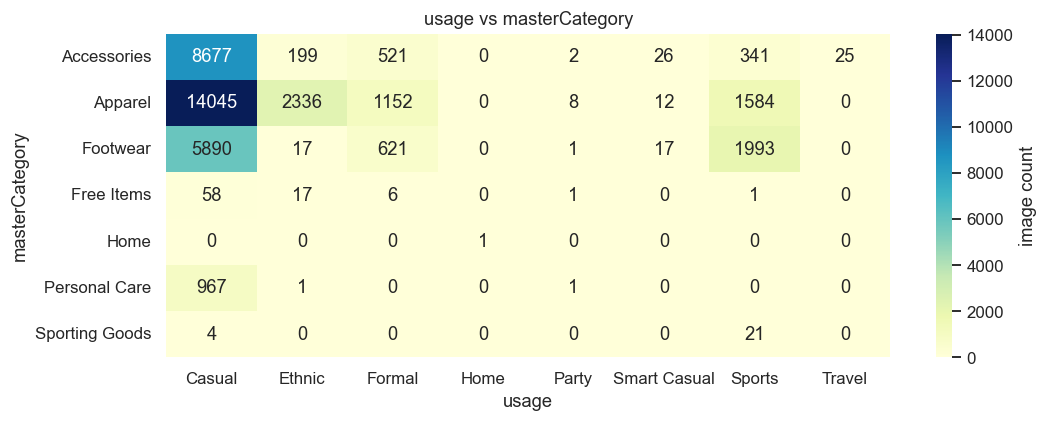

In [16]:
ct = pd.crosstab(df['masterCategory'], df['usage'])
plt.figure(figsize=(10, 4))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'image count'})
plt.title('usage vs masterCategory')
plt.tight_layout(); plt.show()

Casual is spread fairly evenly across Apparel, Footwear, and Accessories, which is part of why the `usage` label is so dominated by it: casual items are common across every kind of product, not concentrated in one category. This suggests the skew reflects the makeup of the catalogue itself rather than a collection error.


### 3.3. `year`

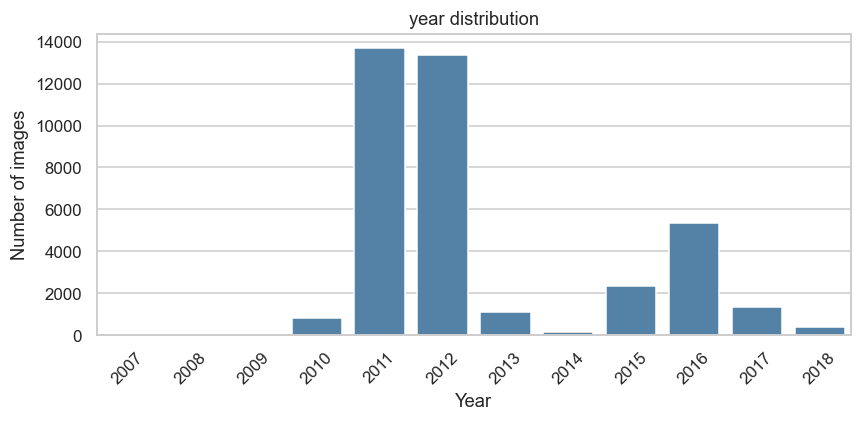

count    38617.000000
mean      2012.611518
std          2.030264
min       2007.000000
25%       2011.000000
50%       2012.000000
75%       2013.000000
max       2018.000000
Name: year, dtype: float64


In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
yc = df['year'].value_counts().sort_index()
sns.barplot(x=yc.index.astype(int), y=yc.values, ax=ax, color='steelblue')
ax.set_title('year distribution')
ax.set_xlabel('Year'); ax.set_ylabel('Number of images')
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()
print(df['year'].describe())

The data is concentrated between 2011 and 2016, with no negative or future years and no obvious anomalies. `year` is not a prediction target, so this is background context only.


## 4. The test set

The test set (`styles_prediction.csv`) is what the final models must fill in, so it is worth checking how it relates to the training data.


In [18]:
pred = pd.read_csv(TEST_CSV)
print('Test set shape:', pred.shape)
print('Test set columns:', list(pred.columns))
print()
print('Train id range:', df['id'].min(), 'to', df['id'].max())
print('Test  id range:', pred['id'].min(), 'to', pred['id'].max())
print('Overlapping ids between train and test:', len(set(df['id']) & set(pred['id'])))
print()
print('Non-null values per column in the test file:')
print(pred.notna().sum())

Test set shape: (5829, 5)
Test set columns: ['id', 'gender', 'articleType', 'season', 'usage']

Train id range: 1163 to 51999
Test  id range: 52003 to 60000
Overlapping ids between train and test: 0

Non-null values per column in the test file:
id             5829
gender            0
articleType       0
season            0
usage             0
dtype: int64


The test file has 5,829 rows and asks for the same four labels (`gender`, `articleType`, `season`, `usage`), all currently empty. Its `id` values run from 52003 to 60000 and do not overlap the training ids at all (which end at 51999), so the split is by product id with no leakage between train and test. Because the labels are blank, the test set cannot be scored locally; model selection has to rely on a validation split carved out of the training data.


## 5. Image exploration

All four tasks are image-based, so we check that the images match the CSV, look at their size and format, and view a few samples. Only a small sample of images is loaded to keep memory use low.


In [19]:
# 5.1. Do the CSV ids match the actual image files?
if os.path.exists(TRAIN_IMG):
    img_files = set(os.listdir(TRAIN_IMG))
    print(f'Files in the train image folder: {len(img_files)}')

    csv_ids = set(df['id'].astype(str) + '.jpg')  # assumes filenames look like "<id>.jpg"
    missing_imgs = csv_ids - img_files
    extra_imgs = img_files - csv_ids

    print(f'CSV ids with no matching image file: {len(missing_imgs)}')
    print(f'Image files with no matching CSV row: {len(extra_imgs)}')
    if missing_imgs:
        print('Example ids with no image:', list(missing_imgs)[:5])
else:
    print('Train image folder not found. Check DATA_DIR before running this cell.')

Files in the train image folder: 38613
CSV ids with no matching image file: 5
Image files with no matching CSV row: 1
Example ids with no image: ['39401.jpg', '39403.jpg', '39425.jpg', '12347.jpg', '39410.jpg']


This cell reports whether every labelled row actually has an image on disk, and whether there are stray image files with no matching row. Any mismatch here is a problem to note now, because rows without an image cannot be used for training. (If the folder is not mounted yet, the cell simply skips.)


In [20]:
# 5.2. Image size and format, estimated from a sample of 200
if os.path.exists(TRAIN_IMG):
    sample_ids = df['id'].sample(min(200, len(df)), random_state=42).astype(str) + '.jpg'
    sizes, modes = [], []
    for fn in sample_ids:
        p = os.path.join(TRAIN_IMG, fn)
        if os.path.exists(p):
            with Image.open(p) as im:
                sizes.append(im.size)   # (width, height)
                modes.append(im.mode)
    if sizes:
        ws = [s[0] for s in sizes]; hs = [s[1] for s in sizes]
        print(f'Sample of {len(sizes)} images:')
        print(f'  Width : min={min(ws)}, max={max(ws)}, most common={pd.Series(ws).mode()[0]}')
        print(f'  Height: min={min(hs)}, max={max(hs)}, most common={pd.Series(hs).mode()[0]}')
        print(f'  Colour modes: {pd.Series(modes).value_counts().to_dict()}')
else:
    print('No image folder found, skipping.')

Sample of 200 images:
  Width : min=60, max=60, most common=60
  Height: min=80, max=80, most common=80
  Colour modes: {'RGB': 198, 'L': 2}


This reports the range of widths and heights and the colour modes in the sample. It tells us whether the images share a common size or vary, and whether they are all RGB, which is what the models will need to account for when reading the images.


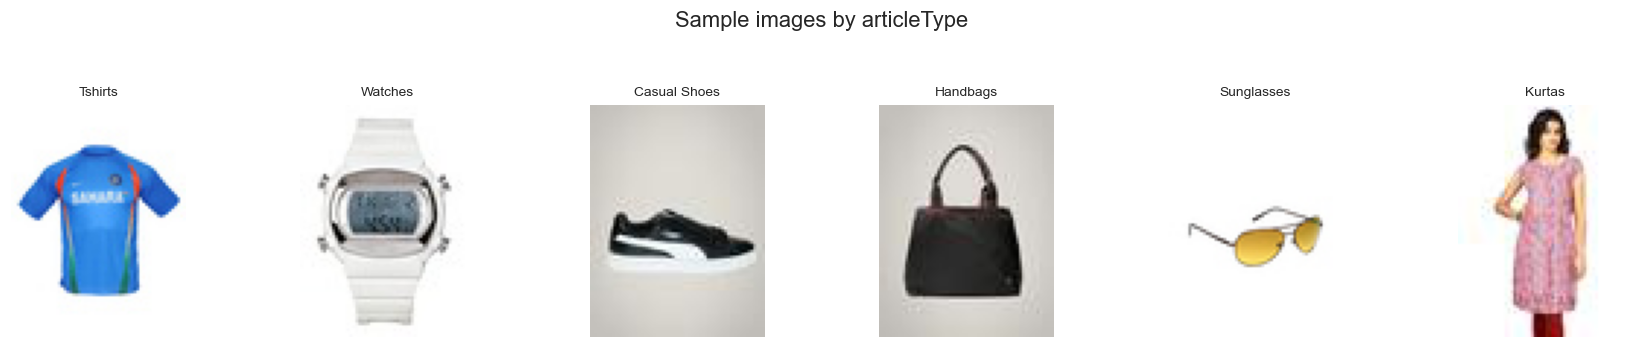

In [21]:
# 5.3. Sample images from a few different classes
if os.path.exists(TRAIN_IMG):
    sample_types = ['Tshirts', 'Watches', 'Casual Shoes', 'Handbags', 'Sunglasses', 'Kurtas']
    fig, axes = plt.subplots(1, len(sample_types), figsize=(16, 3))
    for ax, t in zip(axes, sample_types):
        subset = df[df['articleType'] == t]
        if len(subset) > 0:
            row = subset.iloc[0]
            p = os.path.join(TRAIN_IMG, f"{row['id']}.jpg")
            if os.path.exists(p):
                ax.imshow(Image.open(p))
        ax.set_title(t, fontsize=9)
        ax.axis('off')
    plt.suptitle('Sample images by articleType', y=1.05)
    plt.tight_layout(); plt.show()
else:
    print('No image folder found, skipping.')

These samples give a first look at what the images actually contain: how the products are photographed, whether backgrounds are consistent, and how much detail is visible. That visual sense of the data is useful before deciding anything about how to process the images.


## 6. Summary of findings

The data is structurally clean. The `id` column is a unique key, there are no duplicate rows, missing values are under 0.2% in every column, and the labels are consistently formatted. The only structural quirk is the two extra columns caused by commas in product names, which affects the description text and not the four targets.

The real difficulty is in the label distributions, and it differs by target:

- `gender`: moderately skewed, with Men and Women making up about 91% of the data and Boys and Girls under 4%.
- `season`: the most balanced target, but the season of a product may be hard to read from its image.
- `articleType`: a long tail of 125 classes, with 7 classes holding only a single image and 24 holding 5 or fewer.
- `usage`: dominated by Casual at about 77%, which makes plain accuracy a misleading measure and leaves several classes with only a handful of examples.

The four labels are attached to the same images and are not independent, so some label combinations are common and others barely occur. The test set is a clean id-based split with no overlap with training, and its labels are blank, so validation has to come from a split of the training data.

The open questions these findings raise (what to do about the rare `articleType` classes, how to handle the `usage` skew, which metrics to report, and what image size to standardise on) are for the group to decide together, and are collected separately rather than in this notebook.
